# Capítulo 11 — Accuracy y matriz de confusión

Hasta ahora entrenamos distintos clasificadores y observamos sus predicciones. En este cuaderno comenzaremos a evaluarlas formalmente: compararemos las clases predichas con las clases reales y estudiaremos cómo se distribuyen los aciertos y los errores.

Primero trabajaremos con un ejemplo pequeño, donde podremos revisar cada caso. Luego aplicaremos las mismas ideas a un modelo entrenado con un dataset real.

## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- calcular e interpretar la accuracy;
- construir y leer una matriz de confusión;
- distinguir verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos;
- reconocer que dos clasificadores con la misma accuracy pueden cometer errores diferentes;
- explicar por qué una accuracy alta puede ser engañosa;
- comparar un modelo con una línea de base simple;
- analizar cómo un cambio de umbral modifica los tipos de error.

## 1. Importar las herramientas

Usaremos funciones de `scikit-learn` para calcular la accuracy y construir matrices de confusión. Antes de aplicarlas a un modelo, reproduciremos los cálculos con datos sencillos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 2. Comparar clases reales y predichas

Imaginemos doce casos procesados por un sistema de alertas. La clase `1` significa **requiere revisión** y la clase `0`, **no requiere revisión**.

En este problema decidimos que `1` será la clase positiva. Esta decisión es importante: los nombres “positivo” y “negativo” no expresan algo bueno o malo, sino la forma en que definimos las clases.

In [2]:
y_real = np.array([1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0])
y_pred = np.array([1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0])

condiciones = [
    (y_real == 1) & (y_pred == 1),
    (y_real == 0) & (y_pred == 0),
    (y_real == 0) & (y_pred == 1),
    (y_real == 1) & (y_pred == 0),
]

resultados = [
    "Verdadero positivo",
    "Verdadero negativo",
    "Falso positivo",
    "Falso negativo",
]

casos_alertas = pd.DataFrame({
    "caso": range(1, 13),
    "clase_real": y_real,
    "clase_predicha": y_pred,
    "resultado": np.select(
        condiciones,
        resultados,
        default="Sin clasificar"
    ),
})

casos_alertas

,caso,clase_real,clase_predicha,resultado
0,1,1,1,Verdadero positivo
1,2,0,0,Verdadero negativo
2,3,0,1,Falso positivo
3,4,1,0,Falso negativo
4,5,0,0,Verdadero negativo
5,6,1,1,Verdadero positivo
6,7,0,0,Verdadero negativo
7,8,0,0,Verdadero negativo
8,9,1,1,Verdadero positivo
9,10,0,0,Verdadero negativo


Cada fila compara una observación real con su predicción:

- si ambas clases coinciden, tenemos un acierto;
- si son diferentes, tenemos un error;
- el tipo de acierto o error depende de cuál sea la clase positiva.

En un caso real, un falso positivo podría provocar una revisión innecesaria, mientras que un falso negativo dejaría pasar un caso que sí requería atención.

In [3]:
conteo_resultados = (
    casos_alertas["resultado"]
    .value_counts()
    .rename_axis("tipo")
    .to_frame("cantidad")
)

conteo_resultados

,cantidad
tipo,
Verdadero negativo,6
Verdadero positivo,3
Falso negativo,2
Falso positivo,1


El sistema produjo seis verdaderos negativos y tres verdaderos positivos. Esos nueve casos son aciertos. También produjo un falso positivo y dos falsos negativos.

## 3. Calcular la accuracy

La accuracy responde una pregunta general:

> **¿Qué proporción del total de casos fue clasificada correctamente?**

Podemos calcularla dividiendo la cantidad de aciertos por la cantidad total de predicciones.

In [4]:
cantidad_aciertos = (y_real == y_pred).sum()
cantidad_total = len(y_real)
accuracy_manual = cantidad_aciertos / cantidad_total

pd.DataFrame({
    "aciertos": [cantidad_aciertos],
    "total": [cantidad_total],
    "accuracy": [accuracy_manual],
})

,aciertos,total,accuracy
0,9,12,0.75


La accuracy es `0.75`: el sistema acertó 9 de los 12 casos, es decir, el 75%.

Este valor resume los aciertos totales, pero no muestra cuántos pertenecen a cada clase ni qué tipo de errores se cometieron.

In [5]:
accuracy_sklearn = accuracy_score(y_real, y_pred)

print(f"Accuracy calculada manualmente: {accuracy_manual:.2f}")
print(f"Accuracy con scikit-learn:      {accuracy_sklearn:.2f}")

Accuracy calculada manualmente: 0.75
Accuracy con scikit-learn:      0.75


`accuracy_score()` reproduce el cálculo manual. En una práctica habitual usaremos esta función, pero comprender la fórmula permite interpretar correctamente su resultado.

## 4. Organizar los resultados en una matriz de confusión

La matriz de confusión compara las clases reales con las predichas. Al usar el orden de etiquetas `[0, 1]`, la matriz binaria queda organizada así:

```text
                 Predicho 0   Predicho 1
Real 0               VN           FP
Real 1               FN           VP
```

Las filas representan las clases reales y las columnas, las clases predichas.

In [6]:
matriz_alertas = confusion_matrix(
    y_real,
    y_pred,
    labels=[0, 1]
)

matriz_alertas_df = pd.DataFrame(
    matriz_alertas,
    index=["Real: no requiere", "Real: requiere"],
    columns=["Predicho: no requiere", "Predicho: requiere"],
)

matriz_alertas_df

,Predicho: no requiere,Predicho: requiere
Real: no requiere,6,1
Real: requiere,2,3


La diagonal principal contiene los aciertos: seis verdaderos negativos y tres verdaderos positivos. Fuera de la diagonal aparecen los errores: un falso positivo y dos falsos negativos.

In [7]:
vn, fp, fn, vp = matriz_alertas.ravel()

detalle_matriz = pd.DataFrame({
    "tipo": [
        "Verdadero negativo",
        "Falso positivo",
        "Falso negativo",
        "Verdadero positivo",
    ],
    "cantidad": [vn, fp, fn, vp],
    "interpretacion": [
        "No requería revisión y no se generó alerta",
        "No requería revisión, pero se generó alerta",
        "Requería revisión, pero no se generó alerta",
        "Requería revisión y se generó alerta",
    ],
})

detalle_matriz

,tipo,cantidad,interpretacion
0,Verdadero negativo,6,No requería revisión y no se generó alerta
1,Falso positivo,1,"No requería revisión, pero se generó alerta"
2,Falso negativo,2,"Requería revisión, pero no se generó alerta"
3,Verdadero positivo,3,Requería revisión y se generó alerta


El orden devuelto por `.ravel()` es `VN, FP, FN, VP`. Esta lectura solo es válida porque indicamos explícitamente `labels=[0, 1]` y definimos `1` como clase positiva.

Antes de interpretar cualquier matriz conviene confirmar qué representa cada clase y cómo están ubicadas las filas y las columnas.

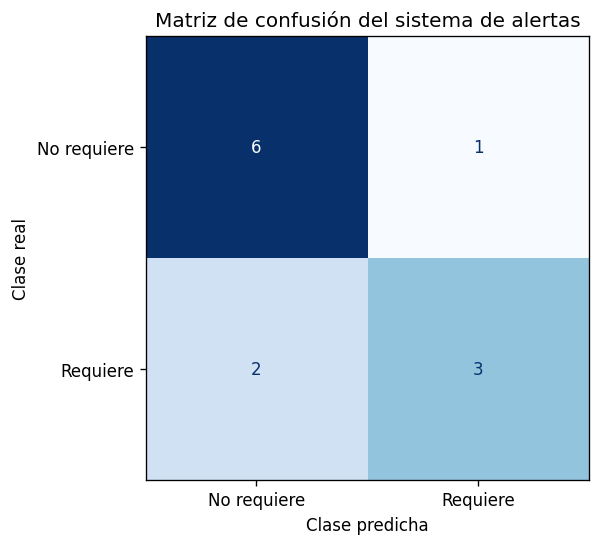

In [8]:
ConfusionMatrixDisplay.from_predictions(
    y_real,
    y_pred,
    labels=[0, 1],
    display_labels=["No requiere", "Requiere"],
    cmap="Blues",
    colorbar=False,
)

plt.title("Matriz de confusión del sistema de alertas")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.show()

La visualización contiene la misma información que la tabla. El color ayuda a reconocer dónde se concentra la mayor cantidad de casos, pero los números siguen siendo lo más importante.

## 5. La misma accuracy puede ocultar errores diferentes

Ahora compararemos dos sistemas. Ambos acertarán nueve de los doce casos, pero distribuirán sus errores de manera distinta.

In [9]:
y_pred_sistema_a = y_pred
y_pred_sistema_b = np.array(
    [1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0]
)

resumen_sistemas = []

for nombre, predicciones in [
    ("Sistema A", y_pred_sistema_a),
    ("Sistema B", y_pred_sistema_b),
]:
    vn_s, fp_s, fn_s, vp_s = confusion_matrix(
        y_real,
        predicciones,
        labels=[0, 1]
    ).ravel()

    resumen_sistemas.append({
        "sistema": nombre,
        "accuracy": accuracy_score(y_real, predicciones),
        "VN": vn_s,
        "FP": fp_s,
        "FN": fn_s,
        "VP": vp_s,
    })

pd.DataFrame(resumen_sistemas)

,sistema,accuracy,VN,FP,FN,VP
0,Sistema A,0.75,6,1,2,3
1,Sistema B,0.75,5,2,1,4


Los dos sistemas tienen accuracy `0.75`. Sin embargo, el Sistema A produce un falso positivo y dos falsos negativos, mientras que el Sistema B produce dos falsos positivos y un falso negativo.

Si fuera especialmente grave dejar pasar casos que requieren revisión, el Sistema B podría resultar preferible. Si cada alerta innecesaria tuviera un costo alto, la decisión podría ser diferente. La accuracy, por sí sola, no permite distinguir estas situaciones.

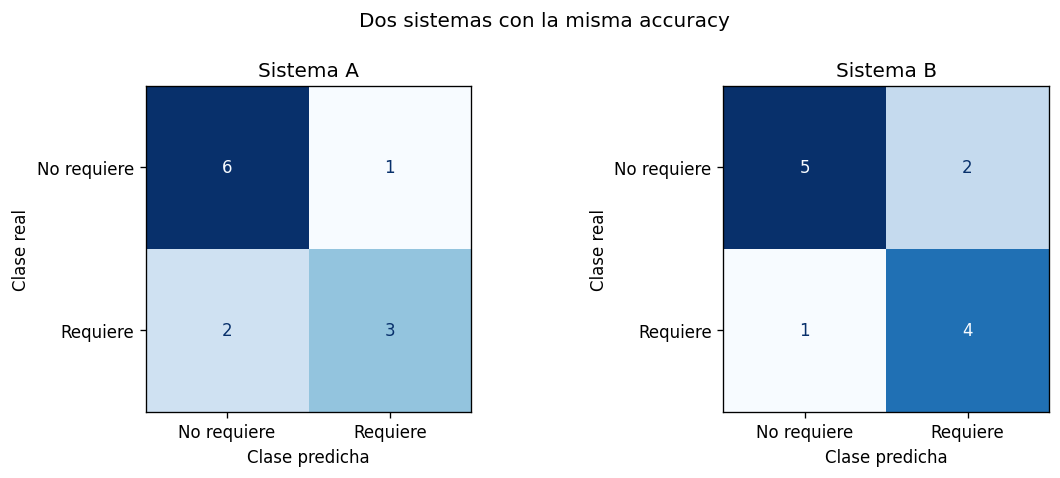

In [10]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 4))

for eje, nombre, predicciones in [
    (ejes[0], "Sistema A", y_pred_sistema_a),
    (ejes[1], "Sistema B", y_pred_sistema_b),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_real,
        predicciones,
        labels=[0, 1],
        display_labels=["No requiere", "Requiere"],
        cmap="Blues",
        colorbar=False,
        ax=eje,
    )
    eje.set_title(nombre)
    eje.set_xlabel("Clase predicha")
    eje.set_ylabel("Clase real")

plt.suptitle("Dos sistemas con la misma accuracy")
plt.tight_layout()
plt.show()

Las matrices muestran por qué no alcanza con preguntar solamente cuántas predicciones fueron correctas. También necesitamos saber **dónde** se encuentran los errores.

## 6. Cuando una accuracy alta puede engañar

Consideremos un problema con 1000 transacciones: 980 normales y 20 fraudulentas. Una estrategia que siempre predice “normal” acertará muchos casos simplemente porque esa es la clase mayoritaria.

In [11]:
y_fraude_real = np.array([0] * 980 + [1] * 20)
y_fraude_pred = np.zeros(1000, dtype=int)

matriz_fraude = confusion_matrix(
    y_fraude_real,
    y_fraude_pred,
    labels=[0, 1]
)

print(
    "Accuracy de la estrategia mayoritaria:",
    f"{accuracy_score(y_fraude_real, y_fraude_pred):.2f}"
)

pd.DataFrame(
    matriz_fraude,
    index=["Real: normal", "Real: fraude"],
    columns=["Predicho: normal", "Predicho: fraude"],
)

Accuracy de la estrategia mayoritaria: 0.98


,Predicho: normal,Predicho: fraude
Real: normal,980,0
Real: fraude,20,0


La accuracy es `0.98`, pero la matriz revela el problema: las 20 transacciones fraudulentas quedaron como falsos negativos. El sistema no detectó ningún fraude.

La estrategia parece buena si solo observamos el porcentaje global de aciertos, pero resulta inútil para el objetivo planteado. Esta es una de las principales limitaciones de la accuracy ante clases desbalanceadas.

## 7. Preparar un dataset real

Trabajaremos con el dataset Breast Cancer Wisconsin incluido en `scikit-learn`. Cada fila contiene mediciones obtenidas a partir de imágenes digitalizadas de muestras celulares.

Lo usaremos únicamente como ejemplo educativo de clasificación. Este cuaderno no constituye una herramienta médica y sus resultados no deben utilizarse para tomar decisiones clínicas.

In [12]:
datos = load_breast_cancer(as_frame=True)

X = datos.data

# En el dataset original, 0 significa maligno y 1 benigno.
# Reordenamos los códigos para definir "maligna" como clase positiva.
y = (datos.target == 0).astype(int)

print(f"Filas:     {X.shape[0]}")
print(f"Variables: {X.shape[1]}")

X.iloc[:5, :6].round(2)

Filas:     569
Variables: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
0,17.99,10.38,122.80,1001.0,0.12,0.28
1,20.57,17.77,132.90,1326.0,0.08,0.08
2,19.69,21.25,130.00,1203.0,0.11,0.16
3,11.42,20.38,77.58,386.1,0.14,0.28
4,20.29,14.34,135.10,1297.0,0.10,0.13


El dataset contiene 569 filas y 30 variables numéricas. La tabla muestra solamente las primeras seis para mantener una salida legible; el modelo utilizará las treinta.

La clase `1` representará una muestra maligna y la clase `0`, una muestra benigna. Esta correspondencia determinará cómo leeremos la matriz de confusión.

In [13]:
distribucion = (
    y.map({0: "Benigna", 1: "Maligna"})
    .value_counts()
    .rename_axis("clase")
    .to_frame("cantidad")
)

distribucion["porcentaje"] = (
    distribucion["cantidad"] / len(y) * 100
)

distribucion.round(1)

,cantidad,porcentaje
clase,,
Benigna,357,62.7
Maligna,212,37.3


Las muestras benignas representan aproximadamente el 62,7% y las malignas el 37,3%. Existe una diferencia entre clases, aunque no es tan extrema como en el ejemplo de fraude.

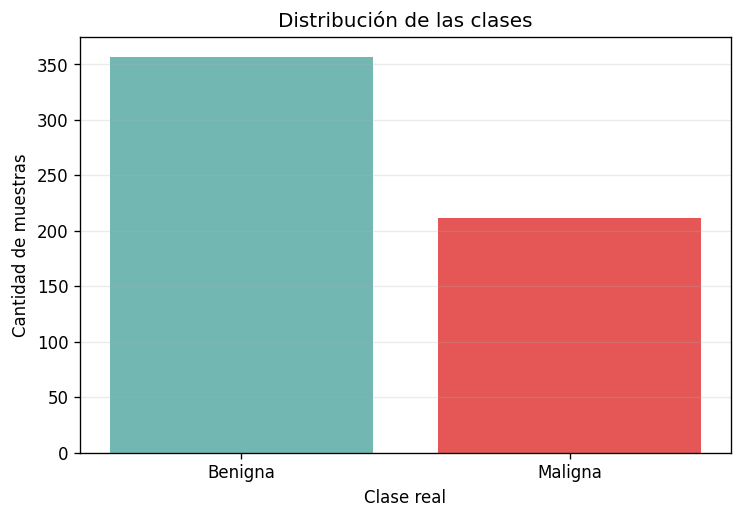

In [14]:
plt.figure(figsize=(7, 4.5))

plt.bar(
    distribucion.index,
    distribucion["cantidad"],
    color=["#72B7B2", "#E45756"],
)

plt.title("Distribución de las clases")
plt.xlabel("Clase real")
plt.ylabel("Cantidad de muestras")
plt.grid(axis="y", alpha=0.25)
plt.show()

El gráfico permite anticipar el desempeño de una línea de base muy simple: si siempre predijera la clase benigna, acertaría cerca del 63% de los casos, pero no identificaría ninguna muestra maligna.

## 8. Separar los datos y entrenar dos clasificadores

Separaremos los datos manteniendo aproximadamente la proporción de clases mediante `stratify=y`.

Entrenaremos una regresión logística y una línea de base que siempre predice la clase mayoritaria. `DummyClassifier` no intenta descubrir un patrón útil: representa una estrategia mínima contra la cual comparar el modelo.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

proporciones = pd.DataFrame({
    "conjunto": ["Entrenamiento", "Prueba"],
    "filas": [len(y_train), len(y_test)],
    "porcentaje_malignas": [
        y_train.mean() * 100,
        y_test.mean() * 100,
    ],
})

proporciones.round(1)

,conjunto,filas,porcentaje_malignas
0,Entrenamiento,426,37.3
1,Prueba,143,37.1


La estratificación conserva una proporción cercana al 37% de muestras malignas en ambos conjuntos. El modelo aprenderá con los datos de entrenamiento y evaluaremos la accuracy sobre las 143 filas de prueba.

In [16]:
modelo_logistico = Pipeline([
    ("escalador", StandardScaler()),
    ("logistica", LogisticRegression(
        max_iter=1000,
        random_state=42,
    )),
])

linea_base = DummyClassifier(strategy="most_frequent")

modelo_logistico.fit(X_train, y_train)
linea_base.fit(X_train, y_train)

print("Clasificadores entrenados.")

Clasificadores entrenados.


La regresión logística y el `Pipeline` ya fueron estudiados en capítulos anteriores. Aquí los utilizamos como herramientas conocidas: el objetivo no es volver a explicar su funcionamiento, sino evaluar sus predicciones.

`max_iter=1000` amplía el número máximo de iteraciones disponibles para que el ajuste pueda completarse.

## 9. Comparar las accuracies

Calcularemos la accuracy de la línea de base y del modelo sobre el mismo conjunto de prueba. Esta comparación aporta un contexto que un valor aislado no ofrece.

In [17]:
pred_base = linea_base.predict(X_test)
pred_logistica = modelo_logistico.predict(X_test)

comparacion_accuracy = pd.DataFrame({
    "clasificador": [
        "Línea de base mayoritaria",
        "Regresión logística",
    ],
    "accuracy": [
        accuracy_score(y_test, pred_base),
        accuracy_score(y_test, pred_logistica),
    ],
})

comparacion_accuracy.round(3)

,clasificador,accuracy
0,Línea de base mayoritaria,0.629
1,Regresión logística,0.965


La línea de base obtiene una accuracy cercana a `0.63` porque siempre elige la clase más frecuente. La regresión logística alcanza aproximadamente `0.97` en esta separación.

El segundo valor es mucho mayor, pero todavía necesitamos observar cómo se distribuyen sus aciertos y errores. Además, describe este dataset y esta separación concreta: no demuestra que el modelo sea perfecto ni que pueda trasladarse automáticamente a un contexto real.

In [18]:
pd.DataFrame({
    "forma_de_calculo": [
        "modelo.score(X_test, y_test)",
        "accuracy_score(y_test, predicciones)",
    ],
    "resultado": [
        modelo_logistico.score(X_test, y_test),
        accuracy_score(y_test, pred_logistica),
    ],
}).round(3)

,forma_de_calculo,resultado
0,"modelo.score(X_test, y_test)",0.965
1,"accuracy_score(y_test, predicciones)",0.965


En los clasificadores de `scikit-learn`, el método `.score()` suele devolver la accuracy. El cálculo explícito con `accuracy_score()` produce el mismo resultado y deja más claro qué métrica estamos usando.

## 10. Comparar las matrices de confusión

Ahora volveremos a las cantidades concretas que originaron las accuracies.

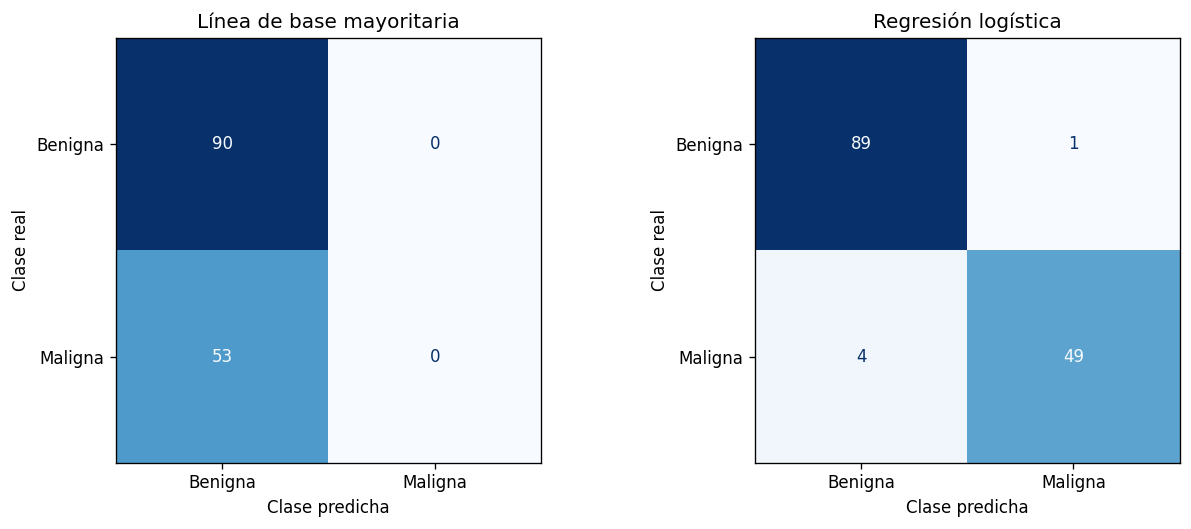

In [19]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4.5))

for eje, titulo, predicciones in [
    (ejes[0], "Línea de base mayoritaria", pred_base),
    (ejes[1], "Regresión logística", pred_logistica),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predicciones,
        labels=[0, 1],
        display_labels=["Benigna", "Maligna"],
        cmap="Blues",
        colorbar=False,
        ax=eje,
    )
    eje.set_title(titulo)
    eje.set_xlabel("Clase predicha")
    eje.set_ylabel("Clase real")

plt.tight_layout()
plt.show()

La línea de base clasifica correctamente las 90 muestras benignas, pero deja las 53 malignas como falsos negativos.

La regresión logística produce 89 verdaderos negativos y 49 verdaderos positivos. Sus errores son un falso positivo y cuatro falsos negativos. La matriz muestra una información que la accuracy no ofrece directamente: qué ocurrió con cada clase.

In [20]:
vn_modelo, fp_modelo, fn_modelo, vp_modelo = confusion_matrix(
    y_test,
    pred_logistica,
    labels=[0, 1]
).ravel()

pd.DataFrame({
    "tipo": [
        "Verdadero negativo",
        "Falso positivo",
        "Falso negativo",
        "Verdadero positivo",
    ],
    "cantidad": [
        vn_modelo,
        fp_modelo,
        fn_modelo,
        vp_modelo,
    ],
})

,tipo,cantidad
0,Verdadero negativo,89
1,Falso positivo,1
2,Falso negativo,4
3,Verdadero positivo,49


Los cuatro falsos negativos representan muestras malignas que el modelo clasificó como benignas. El falso positivo representa una muestra benigna marcada como maligna.

Ambos errores disminuyen la accuracy por igual, pero no necesariamente tendrían las mismas consecuencias en una aplicación real. Evaluar exige vincular cada casilla de la matriz con el contexto del problema.

## 11. Observar el efecto del umbral

La regresión logística produce probabilidades y utiliza habitualmente un umbral de `0.5` para convertirlas en clases. Cambiar ese umbral modifica la cantidad de predicciones positivas y, por lo tanto, la distribución de falsos positivos y falsos negativos.

Compararemos tres umbrales sin buscar todavía un valor óptimo.

In [21]:
prob_maligna = modelo_logistico.predict_proba(X_test)[:, 1]
resultados_umbrales = []

for umbral in [0.3, 0.5, 0.7]:
    pred_umbral = (prob_maligna >= umbral).astype(int)
    vn_u, fp_u, fn_u, vp_u = confusion_matrix(
        y_test,
        pred_umbral,
        labels=[0, 1]
    ).ravel()

    resultados_umbrales.append({
        "umbral": umbral,
        "accuracy": accuracy_score(y_test, pred_umbral),
        "VN": vn_u,
        "FP": fp_u,
        "FN": fn_u,
        "VP": vp_u,
    })

tabla_umbrales = pd.DataFrame(resultados_umbrales)
tabla_umbrales.round(3)

,umbral,accuracy,VN,FP,FN,VP
0,0.3,0.979,89,1,2,51
1,0.5,0.965,89,1,4,49
2,0.7,0.965,90,0,5,48


Al modificar el umbral cambian las cuatro cantidades de la matriz. Un umbral más bajo facilita la predicción de la clase positiva; uno más alto exige una probabilidad mayor.

La mayor accuracy de esta tabla no determina automáticamente el mejor umbral. La elección depende de las consecuencias de los falsos positivos y falsos negativos. En capítulos posteriores incorporaremos métricas que permiten estudiar estas diferencias con más detalle.

## 12. Una pequeña exploración

Modificá `umbral_elegido` con un valor entre 0 y 1. Luego ejecutá la celda y observá cómo cambian la accuracy y los cuatro componentes de la matriz.

In [22]:
umbral_elegido = 0.4

pred_personalizada = (
    prob_maligna >= umbral_elegido
).astype(int)

vn_p, fp_p, fn_p, vp_p = confusion_matrix(
    y_test,
    pred_personalizada,
    labels=[0, 1]
).ravel()

print(f"Umbral:              {umbral_elegido:.2f}")
print(
    "Accuracy:",
    f"{accuracy_score(y_test, pred_personalizada):.3f}"
)
print(f"Verdaderos negativos: {vn_p}")
print(f"Falsos positivos:     {fp_p}")
print(f"Falsos negativos:     {fn_p}")
print(f"Verdaderos positivos: {vp_p}")

Umbral:              0.40
Accuracy: 0.972
Verdaderos negativos: 89
Falsos positivos:     1
Falsos negativos:     3
Verdaderos positivos: 50


Probá, por ejemplo, valores como `0.2`, `0.6` o `0.8`. Antes de decidir cuál te parece preferible, formulá una pregunta concreta: ¿queremos reducir las alertas innecesarias o evitar que pasen casos positivos sin detectar?

## Cierre

La accuracy mide la proporción total de predicciones correctas. Es simple, útil como primera referencia y fácil de comunicar, especialmente cuando las clases están relativamente balanceadas y los errores tienen consecuencias parecidas.

Sin embargo, un único porcentaje no muestra qué clases se predicen bien ni qué tipos de error comete el clasificador. La matriz de confusión permite distinguir verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos, y relacionarlos con el objetivo del problema.

También comprobamos que una estrategia que siempre elige la clase mayoritaria puede alcanzar una accuracy elevada en datos desbalanceados sin detectar ningún caso de interés. Por eso, una evaluación responsable debe considerar la distribución de clases, comparar contra una línea de base y analizar la matriz completa.

En el capítulo siguiente construiremos métricas más específicas a partir de estas cuatro cantidades.

## Para pensar

1. ¿Qué pregunta responde la accuracy?
2. ¿Por qué dos clasificadores con la misma accuracy pueden comportarse de manera diferente?
3. ¿Qué diferencia existe entre un falso positivo y un falso negativo?
4. ¿Por qué una accuracy de `0.98` puede corresponder a un clasificador poco útil?
5. ¿Qué aporta comparar un modelo con una línea de base mayoritaria?
6. ¿Por qué conviene definir la clase positiva antes de interpretar una matriz de confusión?

---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
